In [31]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp
# from xarrayutils.plotting import linear_piecewise_scale


In [32]:
years=400

# 2002 No warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-25_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_2002_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
# label_temp = '2002-2012 - Slow'
# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-25_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_2002_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming
# label_all = '2002-2012 - Slow+Fast'
# start_year = 2002

# 1998 No warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-26_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_1998_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
# label_temp = '1998-2008 - Slow'
# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-25_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_1998_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming
# label_all = '1998-2008 - Slow+Fast'
# start_year = 1998

Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
label_temp = 'Thermo'
Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming
label_all = 'Thermo+Dynamic'
start_year=1990

warming = False
if warming:
    suffix = "_warming"
else:
    suffix = ""

In [33]:
suffix = "very_long"

In [34]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

levels = 19
emulation_stability=True
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 3000
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = np.arange(ds_groundtruth.time.size*repeats)
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 30000))

else:
    ds_groundtruth = ds_input.isel(time=slice(2903, 3503)).isel(lev=slice(None, levels))

ls_temp = ['thetao', 'so', 'zos']
ls_all = ['uo', 'vo', 'thetao', 'so', 'zos']

output_path = "../outputs/" + label_temp+"_"+label_all
print("Using Output Folder : ", output_path)
if not os.path.isdir(os.path.join(output_path)):
    os.makedirs(os.path.join(output_path))


ds_prediction_raw_temp = xr.open_zarr(Pred_path_temp)
ds_prediction_raw_all = xr.open_zarr(Pred_path_all)

# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_all_raw.time.size))

ds_prediction_all = post_processor(
    ds_prediction_raw_all, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_all.time.size)), ls_all
)

ds_prediction_temp = post_processor(
    ds_prediction_raw_temp, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_temp.time.size)), ls_temp
)


# Run the test to make sure the output is formatted correctly
ds_prediction_all = ds_prediction_all.transpose('time','lev',...)
ds_prediction_temp = ds_prediction_temp.transpose('time','lev',...)

Using Output Folder :  ../outputs/Thermo_Thermo+Dynamic


In [35]:
from cftime import DatetimeProlepticGregorian
from datetime import timedelta
dates = np.array(range(3, 365*years, 5))
base = DatetimeProlepticGregorian(start_year,1,1)
all_dates = [base + timedelta(days=int(day-1)) for day in dates]

ds_prediction_temp = ds_prediction_temp.assign_coords(time=all_dates[:ds_prediction_temp.time.size])
ds_prediction_all = ds_prediction_all.assign_coords(time=all_dates[:ds_prediction_all.time.size])

In [36]:
ds_prediction_temp['y']  = ds_prediction_temp.y.assign_attrs(long_name='latitude')
ds_prediction_temp['x']  = ds_prediction_temp.x.assign_attrs(long_name='longitude')
ds_prediction_temp['thetao'] = ds_prediction_temp['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")

ds_prediction_all['y']  = ds_prediction_all.y.assign_attrs(long_name='latitude')
ds_prediction_all['x']  = ds_prediction_all.x.assign_attrs(long_name='longitude')
ds_prediction_all['thetao'] = ds_prediction_all['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")

In [37]:
# ds_prediction_temp = ds_prediction_temp.isel(time=slice(28000, None))

In [38]:
color_2 = '#ff807a'
color_1 = '#1e8685'

In [39]:
# ds_prediction_temp = ds_prediction_temp.isel(time=slice(0,100))
# ds_prediction_all = ds_prediction_all.isel(time=slice(0,100))

OHC portion of upper trend all: 0.64
OHC portion of mid trend all: 0.63
OHC portion of deep trend all: -0.27
OHC portion of upper trend temp: 0.38
OHC portion of mid trend temp: 0.54
OHC portion of deep trend temp: 0.07


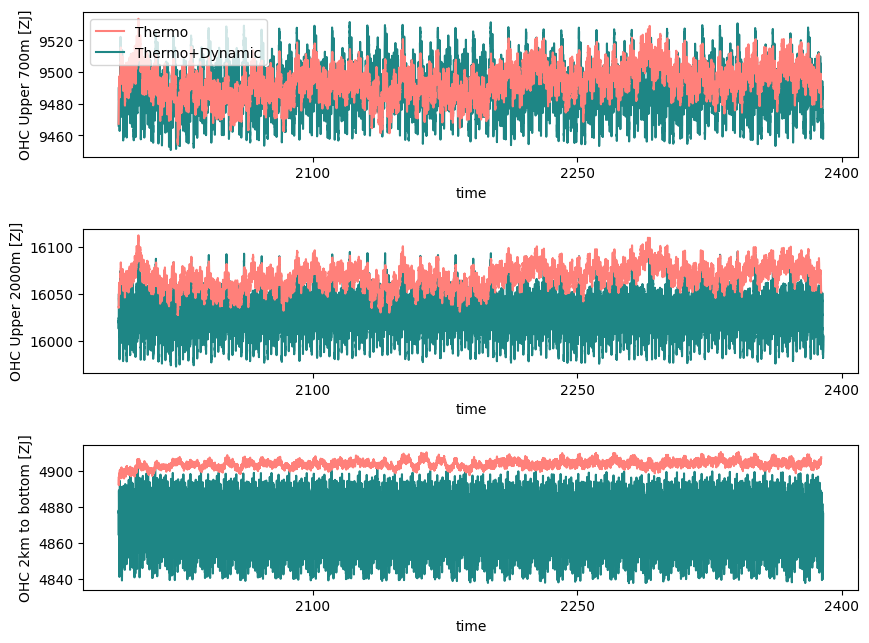

In [41]:
# Compute Basin Heat Content Time Series

Days_to_Eq = 0
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3
zeta_joules_factor = 1e21  # Conversion factor to ZJ


fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred_upper_all = ((ds_prediction_all['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute() / zeta_joules_factor    
OHC_pred_upper_all = OHC_pred_upper_all.rename('OHC Upper 700m')
OHC_pred_upper_all = OHC_pred_upper_all.assign_attrs(units = 'ZJ')
OHC_pred_upper_all.plot(ax = ax[0], label = label_all, c = color_1)
coeffs_OHC_pred_trend_all= np.polyfit(np.arange(OHC_pred_upper_all[Days_to_Eq:].size), OHC_pred_upper_all[Days_to_Eq:], 1)
# ax[0].plot(OHC_pred_upper_all[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_all[Days_to_Eq:].size)*coeffs_OHC_pred_trend_all[0] + coeffs_OHC_pred_trend_all[1],c = color_2, ls = '--')
upper_trend_all = coeffs_OHC_pred_trend_all[0]*73

OHC_pred_upper_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute() / zeta_joules_factor    
OHC_pred_upper_temp = OHC_pred_upper_temp.rename('OHC Upper 700m')
OHC_pred_upper_temp = OHC_pred_upper_temp.assign_attrs(units = 'ZJ')
OHC_pred_upper_temp.plot(ax = ax[0], label = label_temp, c = color_2)
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_upper_temp[Days_to_Eq:].size), OHC_pred_upper_temp[Days_to_Eq:], 1)
# ax[0].plot(OHC_pred_upper_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)

handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles[::-1], labels[::-1])

upper_trend_temp = coeffs_OHC_pred_trend_temp[0]*73



OHC_pred_mid_all = ((ds_prediction_all['thetao'].sel(lev = slice(0,2000))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute() / zeta_joules_factor    
OHC_pred_mid_all = OHC_pred_mid_all.rename('OHC Upper 2000m')
OHC_pred_mid_all = OHC_pred_mid_all.assign_attrs(units = 'ZJ')
OHC_pred_mid_all.plot(ax = ax[1], label = label_all, c = color_1)
coeffs_OHC_pred_trend_all= np.polyfit(np.arange(OHC_pred_mid_all[Days_to_Eq:].size), OHC_pred_mid_all[Days_to_Eq:], 1)
# ax[1].plot(OHC_pred_mid_all[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_all[Days_to_Eq:].size)*coeffs_OHC_pred_trend_all[0] + coeffs_OHC_pred_trend_all[1],c = color_2, ls = '--')
mid_trend_all = coeffs_OHC_pred_trend_all[0]*73

OHC_pred_mid_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(0,2000))*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute() / zeta_joules_factor    
OHC_pred_mid_temp = OHC_pred_mid_temp.rename('OHC Upper 2000m')
OHC_pred_mid_temp = OHC_pred_mid_temp.assign_attrs(units = 'ZJ')
OHC_pred_mid_temp.plot(ax = ax[1], label = label_temp, c = color_2)
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_mid_temp[Days_to_Eq:].size), OHC_pred_mid_temp[Days_to_Eq:], 1)
# ax[1].plot(OHC_pred_mid_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)
mid_trend_temp = coeffs_OHC_pred_trend_temp[0]*73


OHC_pred_deep_all = ((ds_prediction_all['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute() / zeta_joules_factor     
OHC_pred_deep_all = OHC_pred_deep_all.rename('OHC 2km to bottom')
OHC_pred_deep_all = OHC_pred_deep_all.assign_attrs(units = 'ZJ')
OHC_pred_deep_all.plot(ax = ax[2], label = label_all, c = color_1)
coeffs_OHC_pred_trend_all= np.polyfit(np.arange(OHC_pred_deep_all[Days_to_Eq:].size), OHC_pred_deep_all[Days_to_Eq:], 1)
# ax[2].plot(OHC_pred_deep_all[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_all[Days_to_Eq:].size)*coeffs_OHC_pred_trend_all[0] + coeffs_OHC_pred_trend_all[1],c = color_2, ls = '--')
# ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)
deep_trend_all = coeffs_OHC_pred_trend_all[0]*73


OHC_pred_deep_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute() / zeta_joules_factor     
OHC_pred_deep_temp = OHC_pred_deep_temp.rename('OHC 2km to bottom')
OHC_pred_deep_temp = OHC_pred_deep_temp.assign_attrs(units = 'ZJ')
OHC_pred_deep_temp.plot(ax = ax[2], label = label_temp, c = color_2)
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_deep_temp[Days_to_Eq:].size), OHC_pred_deep_temp[Days_to_Eq:], 1)
# ax[2].plot(OHC_pred_deep_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)
deep_trend_temp = coeffs_OHC_pred_trend_temp[0]*73

total_trend_all = upper_trend_all + mid_trend_all + deep_trend_all
total_trend_temp = upper_trend_temp + mid_trend_temp + deep_trend_temp

print(f'OHC portion of upper trend all: {upper_trend_all/total_trend_all:.2f}')
print(f'OHC portion of mid trend all: {mid_trend_all/total_trend_all:.2f}')
print(f'OHC portion of deep trend all: {deep_trend_all/total_trend_all:.2f}')

print(f'OHC portion of upper trend temp: {upper_trend_temp/total_trend_temp:.2f}')
print(f'OHC portion of mid trend temp: {mid_trend_temp/total_trend_temp:.2f}')
print(f'OHC portion of deep trend temp: {deep_trend_temp/total_trend_temp:.2f}')

plt.savefig("../Figures/OHC_Depth_Very_Long", bbox_inches='tight', dpi=600)
# plt.show()

2.6536372019103454e-24
4.808329506262404e-23
-1.3973037335376014e-25
1.8671380893510655e-24


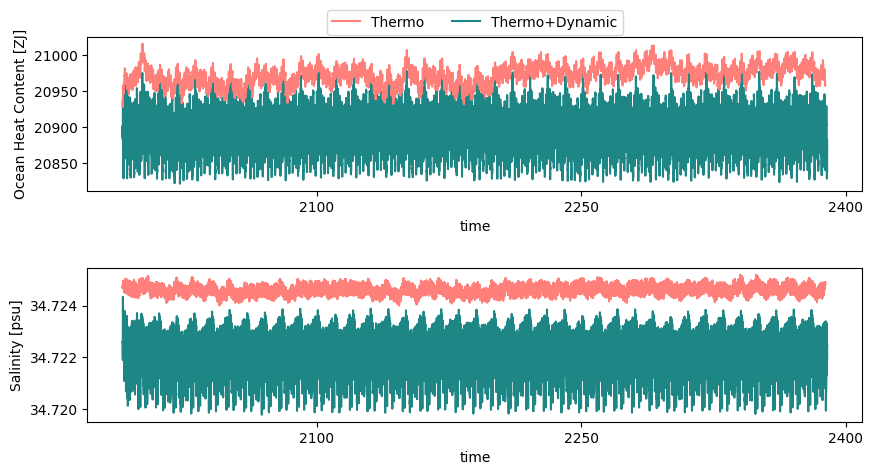

In [40]:
Days_to_Eq = 0

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3
zeta_joules_factor = 1e21  # Conversion factor to ZJ

fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})


OHC_pred_all = (ds_prediction_all['thetao'][Days_to_Eq:]*c_p*rho_0).weighted(ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute() / zeta_joules_factor    
OHC_pred_all = OHC_pred_all.rename('Ocean Heat Content')
OHC_pred_all = OHC_pred_all.assign_attrs(units = 'ZJ')
OHC_pred_all.plot(ax = ax[0], label = label_all, c = color_1)
coeffs_OHC_pred_trend_all= np.polyfit(np.arange(OHC_pred_all[:].size), OHC_pred_all[:], 1)

OHC_pred_temp = (ds_prediction_temp['thetao'][Days_to_Eq:]*c_p*rho_0).weighted(ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute() / zeta_joules_factor    
OHC_pred_temp = OHC_pred_temp.rename('Ocean Heat Content')
OHC_pred_temp = OHC_pred_temp.assign_attrs(units = 'ZJ')
OHC_pred_temp.plot(ax = ax[0], label = label_temp, c = color_2)
coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp[:].size), OHC_pred_temp[:], 1)
# ax[0].plot(OHC_pred_temp[:].time.data, np.arange(OHC_pred_temp[:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles[::-1], labels[::-1], loc='upper center', bbox_to_anchor=(0.5, 1.22), ncol=2)


salinity_all = (ds_prediction_all['so'][Days_to_Eq:]).weighted(ds_prediction_all['areacello']*ds_prediction_all['dz']).mean(['x','y','lev']).compute()     
salinity_all = salinity_all.rename('Salinity')
salinity_all = salinity_all.assign_attrs(units = 'psu')
salinity_all.plot(ax = ax[1], label = label_all, c = color_1)
coeffs_salinity_trend_all= np.polyfit(np.arange(salinity_all[:].size), salinity_all[:], 1)

salinity_temp = (ds_prediction_temp['so'][Days_to_Eq:]).weighted(ds_prediction_temp['areacello']*ds_prediction_temp['dz']).mean(['x','y','lev']).compute()     
salinity_temp = salinity_temp.rename('Salinity')
salinity_temp = salinity_temp.assign_attrs(units = 'psu')
salinity_temp.plot(ax = ax[1], label = label_temp, c = color_2)
coeffs_salinity_trend_temp= np.polyfit(np.arange(salinity_temp[:].size), salinity_temp[:], 1)
# ax[1].plot(salinity_temp[:].time.data, np.arange(salinity_temp[:].size)*coeffs_salinity_trend_temp[0] + coeffs_salinity_trend_temp[1],c = color_2, ls = '--')


print(coeffs_OHC_pred_trend_all[0]*73)
print(coeffs_OHC_pred_trend_temp[0]*73)
print(coeffs_salinity_trend_all[0]*73)
print(coeffs_salinity_trend_temp[0]*73)
plt.savefig("../Figures/OHC_Salinity_Very_Long", bbox_inches='tight', dpi=600)
# plt.show()


In [42]:
print(coeffs_OHC_pred_trend_all[0]*73)
print(coeffs_OHC_pred_trend_temp[0]*73)
print(coeffs_salinity_trend_all[0]*73)
print(coeffs_salinity_trend_temp[0]*73)

-0.001970678144095015
0.005725167948548967
-1.3973037335376014e-08
1.8671380893510656e-07
